# Тест 2 — может ли ошибка в потоке мюонов объяснить избыток

## Что проверяем

Гипотеза **(a)** говорит: отклик детектора смоделирован верно, а неверна
*популяция* — генератор производит не то распределение мюонов, которое приходит
в детектор на самом деле. Если так, то какая-то весовая функция над **истинными**
переменными симуляции обязана устранить расхождение.

Истинные переменные — это то, что известно про событие в симуляции, но не
измеряется в данных: зенитный угол мюона и энергия первичной частицы. В нашей
базе доступны именно эти две.

## Почему тест имеет силу

Две истинные оси против дюжины наблюдаемых величин. Задача **переопределена**:
ошибка потока обязана исправляться одной низкоразмерной функцией сразу везде, а
ошибка отклика так исправиться не может.

Подгонка при этом устроена так, что свободы у неё заведомо больше, чем
ограничений — 60 ячеек истины против 12 полос скора. Поэтому **сама по себе
удачная подгонка ничего не доказывает** и заложена в конструкцию. Содержание
теста в другом: какой ценой она достигается и что происходит с величинами, в
подгонке не участвовавшими.

## Соглашение о зените

Здесь и далее **90° — горизонт, 180° — строго вниз**. В симуляции мюоны идут
только сверху, поэтому зенит всегда больше 90°.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present

present.glossary(["muatm", "скор ξ", "избыток", "полоса", "отбор качества"])
DATA = HERE / "data"
fit = pd.read_parquet(DATA / "20_score_fit.parquet")
sweep = pd.read_parquet(DATA / "20_smoothness_sweep.parquet")
bound = pd.read_parquet(DATA / "20_achievable_bound.parquet")
weights = pd.read_parquet(DATA / "20_weights.parquet")
held = pd.read_parquet(DATA / "20_held_out.parquet")
BLUE, ORANGE, TEAL, PINK, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#c9268a", "#0b0b0b", "#52514e", "#fcfcfb")

         muatm  —  симулированные атмосферные мюоны — фон, который мы умеем считать
        скор ξ  —  выход классификатора от 0 до 1; чем выше, тем больше событие похоже на
                   нейтрино по мнению сети
       избыток  —  во сколько раз доля экспериментальных событий в данной области скора больше
                   такой же доли у симулированных мюонов. Единица означала бы согласие
        полоса  —  интервал скора, например 0.8–0.9
отбор качества  —  n_sn_hits ≥ 8 и n_sn_strings ≥ 3 — не меньше восьми сигнальных хитов не менее
                   чем на трёх струнах; применяется к обеим выборкам одинаково


## Шаг 1. Подгонка сходится — и это ничего не значит

Ищем вес для каждой ячейки истины так, чтобы распределение симулированных
событий по скору совпало с экспериментальным.

In [2]:
present.show(
    fit,
    {"score_lo": "полоса от", "score_hi": "полоса до",
     "mc_share": "доля МК до перевзвешивания",
     "mc_share_reweighted": "доля МК после",
     "exp_share": "доля exp",
     "excess_before": "избыток до", "excess_after": "избыток после"},
    rows="одна полоса скора",
    source=present.artefact_note(DATA / "20_score_fit.parquet"),
    note="Все полосы приходят к единице с исходных 0.98–4.39. Ожидаемо: 60 "
         "свободных весов против 12 ограничений. Вопрос не «получилось ли», а "
         "«каким весом».",
    decimals=4)

Строка — одна полоса скора.
Все полосы приходят к единице с исходных 0.98–4.39. Ожидаемо: 60 свободных весов против 12
ограничений. Вопрос не «получилось ли», а «каким весом».
Источник: стадия 20_flux_reweight, файл 20_score_fit.parquet, 12 строк


полоса от,полоса до,доля МК до перевзвешивания,доля МК после,доля exp,избыток до,избыток после
0.000000,0.010000,0.975900,0.960200,0.960000,0.983800,0.999800
0.010000,0.050000,0.013700,0.022700,0.023000,1.684600,1.013000
0.050000,0.100000,0.003100,0.005300,0.005300,1.685300,0.992800
0.100000,0.200000,0.002700,0.004200,0.004000,1.467500,0.951400
0.200000,0.300000,0.001500,0.002100,0.002000,1.348700,0.963700
0.300000,0.500000,0.001600,0.002500,0.002400,1.470300,0.977900
0.500000,0.700000,0.000900,0.001500,0.001700,1.908500,1.101700
0.700000,0.800000,0.000300,0.000600,0.000600,2.256700,1.053600
0.800000,0.900000,0.000200,0.000500,0.000500,2.706000,1.101900
0.900000,0.950000,0.000100,0.000200,0.000200,2.809300,0.977900


## Шаг 2. Точная граница: что вообще достижимо перевзвешиванием

Это главный результат теста, и он не является результатом подгонки.

Если вес `w` зависит только от истины `T`, то перевзвешенная доля принятых равна
`E[w(T)·a(T)] / E[w(T)]`, где `a(T)` — доля принятых симулированных событий при
данной истине. Максимум такого отношения при ограничении `w ∈ [1/√R, √R]`
достигается в вершине: поднять все ячейки, где `a` выше некоторого порога, и
опустить остальные. Сортировка по `a` и перебор порога дают **точный** максимум,
который не может побить никакая подгонка.

`R` — во сколько раз самый большой вес отличается от самого маленького. Это мера
того, насколько сильно приходится искажать поток. `R = 2` означает поправку
максимум вдвое, `R = 100` — в сто раз.

In [3]:
top = bound[bound.score_lo >= 0.8].copy()
top["band"] = top.apply(lambda r: f"{r.score_lo:.2f}–{min(r.score_hi, 1.0):.2f}", axis=1)
present.show(
    top.pivot(index="weight_range", columns="band",
              values="max_enhancement").reset_index(),
    {"weight_range": "допустимый размах веса R",
     **{b: f"полоса {b}" for b in sorted(top.band.unique())}},
    rows="одно ограничение на размах веса",
    source=present.artefact_note(DATA / "20_achievable_bound.parquet"),
    note="В клетках — максимально достижимое усиление доли принятых. Сравнивать "
         "надо с наблюдаемым избытком в той же полосе (таблица ниже).",
    decimals=2)
present.show(
    top[top.weight_range == 2.0],
    {"band": "полоса", "observed_excess": "наблюдаемый избыток",
     "max_enhancement": "максимум достижимого при R = 2",
     "reachable": "достижимо?"},
    rows="одна полоса скора",
    source="та же таблица",
    note="При R = 2 не достижимо НИ В ОДНОЙ полосе. При R = 4 (см. таблицу выше) "
         "не достижимо в двух верхних. Наблюдаемый избыток становится возможен "
         "только начиная примерно с R = 10.",
    decimals=2)

Строка — одно ограничение на размах веса.
В клетках — максимально достижимое усиление доли принятых. Сравнивать надо с наблюдаемым
избытком в той же полосе (таблица ниже).
Источник: стадия 20_flux_reweight, файл 20_achievable_bound.parquet, 24 строки


допустимый размах веса R,полоса 0.80–0.90,полоса 0.90–0.95,полоса 0.95–0.99,полоса 0.99–1.00
2.000000,1.760000,1.760000,1.760000,1.770000
4.000000,3.010000,3.050000,3.050000,3.140000
10.000000,5.990000,6.140000,6.090000,6.590000
100.000000,25.710000,26.940000,26.200000,29.290000
10000.000000,180.910000,186.430000,193.400000,229.050000
1000000000.000000,734.140000,852.170000,2383.900000,19756.330000


Строка — одна полоса скора.
При R = 2 не достижимо НИ В ОДНОЙ полосе. При R = 4 (см. таблицу выше) не достижимо в двух
верхних. Наблюдаемый избыток становится возможен только начиная примерно с R = 10.
Источник: та же таблица


полоса,наблюдаемый избыток,максимум достижимого при R = 2,достижимо?
0.80–0.90,2.710000,1.760000,False
0.90–0.95,2.810000,1.760000,False
0.95–0.99,3.290000,1.760000,False
0.99–1.00,4.390000,1.770000,False


## Шаг 3. Сколько стоит правдоподобность веса

Первая версия этой стадии подгоняла веса методом неотрицательных наименьших
квадратов. Она обнулила 24 ячейки, содержавшие 65% симулированной выборки, и дала
U-образный профиль по зениту. Подгонка, удаляющая две трети выборки, ничего не
доказывает, поэтому стадия переписана: вес ищется в виде `exp(θ)` (обнулиться не
может), а на разность θ между соседними ячейками накладывается штраф за
негладкость.

Параметр `λ` — сила этого штрафа. Чем он больше, тем более гладким и умеренным
обязан быть вес, то есть тем правдоподобнее он как поправка к потоку.

In [4]:
present.show(
    sweep,
    {"smoothness": "штраф за негладкость λ",
     "max_abs_excess_dev": "худшая полоса промахивается на",
     "median_abs_excess_dev": "медианная полоса промахивается на",
     "weight_ratio": "потребовавшийся размах веса R",
     "mc_frac_suppressed": "доля МК, задавленная почти в ноль"},
    rows="одна настройка штрафа",
    source=present.artefact_note(DATA / "20_smoothness_sweep.parquet"),
    note="«Промахивается на 0.10» значит, что избыток после перевзвешивания "
         "равен 1.10 или 0.90 вместо единицы. Чтобы уложить все полосы в 10%, "
         "весу нужен размах ×131. При правдоподобном ×4 худшая полоса "
         "промахивается на 98% — то есть коррекции практически нет.",
    decimals=3)

Строка — одна настройка штрафа.
«Промахивается на 0.10» значит, что избыток после перевзвешивания равен 1.10 или 0.90 вместо
единицы. Чтобы уложить все полосы в 10%, весу нужен размах ×131. При правдоподобном ×4 худшая
полоса промахивается на 98% — то есть коррекции практически нет.
Источник: стадия 20_flux_reweight, файл 20_smoothness_sweep.parquet, 6 строк


штраф за негладкость λ,худшая полоса промахивается на,медианная полоса промахивается на,потребовавшийся размах веса R,"доля МК, задавленная почти в ноль"
0.000000,0.070000,0.005000,52359788578.695000,0.803000
0.100000,0.016000,0.008000,1458.696000,0.000000
1.000000,0.087000,0.008000,370.393000,0.000000
10.000000,0.102000,0.029000,131.015000,0.000000
100.000000,0.486000,0.152000,16.150000,0.000000
1000.000000,0.985000,0.178000,3.780000,0.000000


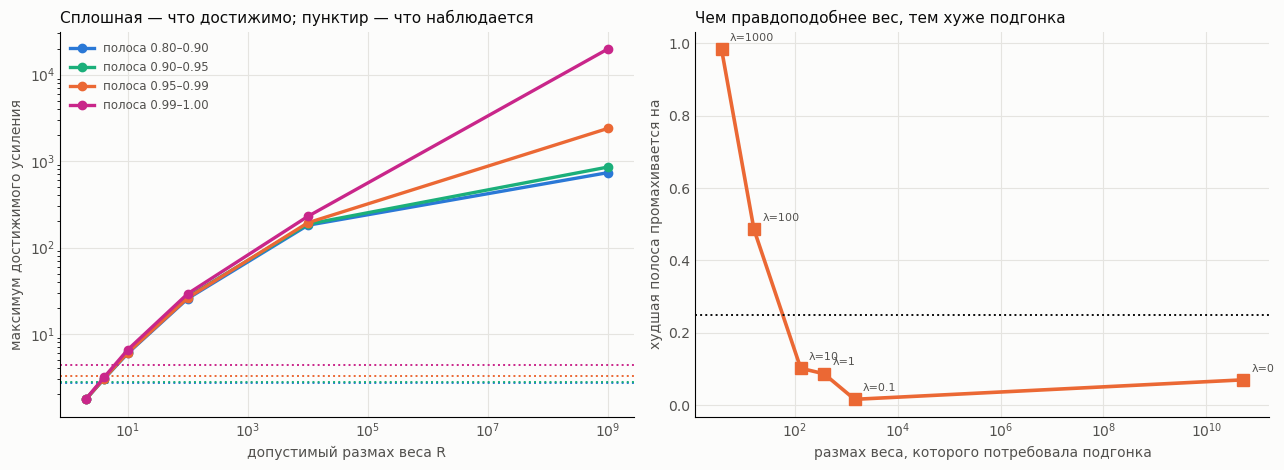

Слева точка пересечения сплошной кривой с пунктиром своего цвета —
минимальный размах веса, при котором наблюдаемое становится возможным.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.patch.set_facecolor(SURFACE)
for ax in axes:
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", lw=0.8)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
ax = axes[0]
for (lo, hi), colour in zip(sorted(set(zip(bound.score_lo, bound.score_hi))),
                            [BLUE, TEAL, ORANGE, PINK]):
    sub = bound[bound.score_lo == lo].sort_values("weight_range")
    ax.plot(sub.weight_range, sub.max_enhancement, "o-", color=colour, lw=2.4,
            ms=6, label=f"полоса {lo:.2f}–{min(hi, 1.0):.2f}")
    ax.axhline(sub.observed_excess.iloc[0], color=colour, ls=":", lw=1.4)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("допустимый размах веса R", color=MUTED)
ax.set_ylabel("максимум достижимого усиления", color=MUTED)
ax.set_title("Сплошная — что достижимо; пунктир — что наблюдается",
             loc="left", fontsize=11, color=INK)
ax.legend(frameon=False, fontsize=8.5, labelcolor=MUTED)
ax = axes[1]
ax.plot(sweep.weight_ratio, sweep.max_abs_excess_dev, "s-", color=ORANGE,
        lw=2.6, ms=8)
for _, row in sweep.iterrows():
    ax.annotate(f"λ={row.smoothness:g}", (row.weight_ratio, row.max_abs_excess_dev),
                textcoords="offset points", xytext=(6, 6), fontsize=8, color=MUTED)
ax.axhline(0.25, color=INK, ls=":", lw=1.4)
ax.set_xscale("log")
ax.set_xlabel("размах веса, которого потребовала подгонка", color=MUTED)
ax.set_ylabel("худшая полоса промахивается на", color=MUTED)
ax.set_title("Чем правдоподобнее вес, тем хуже подгонка", loc="left",
             fontsize=11, color=INK)
plt.tight_layout()
plt.savefig(HERE / "figures" / "20_flux_reweight.png", dpi=150,
            bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("Слева точка пересечения сплошной кривой с пунктиром своего цвета —")
print("минимальный размах веса, при котором наблюдаемое становится возможным.")

## Шаг 4. Какой формы должен быть вес

Даже если закрыть глаза на размах, посмотрим, что именно требуется от потока.

In [6]:
occupied = weights[weights.mc_events > 0]
shape = occupied.groupby(["zenith_lo", "zenith_hi"]).apply(
    lambda x: pd.Series({"weight": np.average(x.weight, weights=x.mc_events),
                         "mc_events": x.mc_events.sum()}),
    include_groups=False).reset_index()
present.show(
    shape,
    {"zenith_lo": "зенит от, °", "zenith_hi": "зенит до, °",
     "weight": "требуемый множитель к потоку",
     "mc_events": "сколько МК-событий в этом диапазоне"},
    rows="один диапазон зенитного угла (90° = горизонт, 180° = вертикаль вниз)",
    source=present.artefact_note(DATA / "20_weights.parquet"),
    note="Требуется усилить окологоризонтальные мюоны примерно вдесятеро и "
         "одновременно подавить основную массу почти вдвое. Основная масса "
         "нисходящих мюонов измерена во множестве экспериментов, и её "
         "двукратное подавление трудно назвать правдоподобной поправкой.",
    decimals=2)

Строка — один диапазон зенитного угла (90° = горизонт, 180° = вертикаль вниз).
Требуется усилить окологоризонтальные мюоны примерно вдесятеро и одновременно подавить основную
массу почти вдвое. Основная масса нисходящих мюонов измерена во множестве экспериментов, и её
двукратное подавление трудно назвать правдоподобной поправкой.
Источник: стадия 20_flux_reweight, файл 20_weights.parquet, 60 строк


"зенит от, °","зенит до, °",требуемый множитель к потоку,сколько МК-событий в этом диапазоне
90,95.000000,9.730000,43.000000
95,100.000000,12.200000,16331.000000
100,105.000000,4.390000,151567.000000
105,110.000000,2.200000,506841.000000
110,115.000000,0.950000,1087543.000000
115,120.000000,0.570000,1689019.000000
120,130.000000,0.410000,4749463.000000
130,140.000000,0.510000,5356581.000000
140,155.000000,1.660000,6669520.000000
155,180.100000,1.170000,2944689.000000


## Шаг 5. Отложенные наблюдаемые

Дюжина величин, которые в подгонке не участвовали: суммарный заряд, число
модулей, временная и пространственная протяжённость события. Если ошибка
действительно в потоке, найденный вес обязан улучшить и их.

Расхождение меряется расстоянием Вассерштейна — насколько далеко надо «перевезти»
одно распределение, чтобы получить другое; нормировано на разброс, чтобы величины
в разных единицах были сравнимы.

In [7]:
pivot = held.pivot(index="observable", columns="region",
                   values="fraction_removed").reset_index()
cols = {"observable": "наблюдаемая"}
cols.update({c: f"снято рассогласования: {c}" for c in pivot.columns if c != "observable"})
present.show(
    pivot.sort_values(pivot.columns[1]),
    cols,
    rows="одна наблюдаемая величина",
    source=present.artefact_note(DATA / "20_held_out.parquet"),
    note="Положительное число — вес приблизил симуляцию к данным; отрицательное "
         "— отдалил. Медиана отрицательная: найденный вес в среднем делает "
         "согласие ХУЖЕ. Часть величин улучшается (заряд в области отбора на "
         "45%), большинство ухудшается.",
    decimals=2)

Строка — одна наблюдаемая величина.
Положительное число — вес приблизил симуляцию к данным; отрицательное — отдалил. Медиана
отрицательная: найденный вес в среднем делает согласие ХУЖЕ. Часть величин улучшается (заряд в
области отбора на 45%), большинство ухудшается.
Источник: стадия 20_flux_reweight, файл 20_held_out.parquet, 26 строк


наблюдаемая,снято рассогласования: accepted (score>=0.8),снято рассогласования: all quality
z_c,-2.680000,-0.160000
n_channels,-1.790000,-8.370000
prob_mean,-1.250000,-0.850000
xy_span,-1.170000,-0.960000
t_span_core,-0.740000,-0.440000
n_sig_strings,-0.730000,0.070000
t_span,-0.560000,-0.760000
r_vert,-0.330000,-0.370000
z_span,-0.290000,-0.620000
q_frac_max,0.000000,-1.170000


## Вывод

Три линии сходятся, и все против (a):

1. **Граница достижимого.** Перевзвешивание с размахом ×2 не даёт нужного
   усиления нигде, с ×4 — не даёт в двух верхних полосах. Это точная граница, не
   результат оптимизации: она верна для оптимального веса, без требования
   гладкости и без оглядки на остальные величины.
2. **Цена подгонки.** Чтобы закрыть все полосы, нужен размах ×131 и подавление
   хорошо измеренной основной массы вдвое.
3. **Отложенные величины.** Найденный вес делает их в среднем хуже.

**Чего тест не доказывает.** Истинных осей было две. Кратность мюонов проверена
отдельно и рычага почти не имеет (AUC 0.56 при разделении ложных срабатываний,
отчёт 2026-08-10), но **прицельного параметра у нас нет вовсе**. Ошибка потока,
живущая в недоступной переменной, этим тестом не поймается: граница считается в
том пространстве истины, которое есть.

Формально: **(a) в доступных истинных переменных требует искажения потока не
меньше чем в 4–10 раз, сосредоточенного у горизонта, и даже тогда портит
наблюдаемые.**

**Что дальше.** Тест 1 (`30_response.ipynb`) проверяет альтернативу (b) — что
неверен отклик детектора.